# Multi-Object Detection & Persistent ID Tracking
**Pipeline:** YOLOv8m + ByteTrack | **Author:** Shruti Sharma

| Stage | Tool | Why |
|---|---|---|
| Detection | YOLOv8m | Best speed/accuracy tradeoff for occluded persons |
| Tracking | ByteTrack | Two-stage IoU matching recovers low-conf detections |
| Post-filter | Stationary filter | Suppresses crowd/spectator detections |

## 1 — Install Dependencies

In [1]:
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2, numpy as np, matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
import time, os

versions = {
    'ultralytics': __import__('ultralytics').__version__,
    'supervision':  sv.__version__,
    'opencv':       cv2.__version__,
    'numpy':        np.__version__,
}
print(f"{'Library':<15} {'Version'}")
print('─' * 28)
for name, ver in versions.items():
    print(f'{name:<15} {ver}')
print('\nAll dependencies ready.')

Note: you may need to restart the kernel to use updated packages.
Library         Version
────────────────────────────
ultralytics     8.4.33
supervision     0.27.0.post2
opencv          4.13.0
numpy           2.3.5

All dependencies ready.


## 2 — Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
VIDEO_PATH  = os.path.join(os.getcwd(), 'input.mp4')
OUTPUT_PATH = os.path.join(os.getcwd(), 'output.mp4')
MODEL_PATH  = 'yolov8m.pt'

# ── Detection ─────────────────────────────────────────────────────────────────
CONF_THRESH  = 0.4    # Min detection confidence
MIN_BOX_AREA = 1500    # Min bounding-box area in px² (strips partial bodies)

# ── ByteTrack ─────────────────────────────────────────────────────────────────
TRACK_THRESH = 0.5    # Min conf to SPAWN a new track (prevents re-entry ghost IDs)
MATCH_THRESH = 0.85    # IoU association threshold
BUFFER_SIZE  = 1200      # Frames to keep a lost track alive (2 s @ 30 fps)
MIN_HITS     = 5       # Frames before an ID is assigned

# ── Stationary-person filter ───────────────────────────────────────────────────
STATIONARY_FRAMES = 300   # 10 s @ 30 fps
STATIONARY_PIXELS = 20    # Centroid drift threshold (px)

# ── Validate & read video metadata ────────────────────────────────────────────
assert os.path.isfile(VIDEO_PATH), f'Video not found: {VIDEO_PATH}'

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f'Video  : {WIDTH}×{HEIGHT} @ {FPS:.0f} fps  —  {TOTAL} frames ({TOTAL/FPS:.0f} s)')
print(f'Output : {OUTPUT_PATH}')
print(f'\nTracker config:')
print(f'  conf_thresh       = {CONF_THRESH}')
print(f'  min_box_area      = {MIN_BOX_AREA} px²')
print(f'  track_thresh      = {TRACK_THRESH}')
print(f'  match_thresh      = {MATCH_THRESH}')
print(f'  buffer_size       = {BUFFER_SIZE} frames')
print(f'  min_hits          = {MIN_HITS} frames')
print(f'  stationary_frames = {STATIONARY_FRAMES} frames')
print(f'  stationary_pixels = {STATIONARY_PIXELS} px')

Video  : 1280×720 @ 30 fps  —  1800 frames (60 s)
Output : C:\Users\Shruti Sharma\OneDrive\Documents\Motion-Object-Tracking\mot-tracker\notebooks\output.mp4

Tracker config:
  conf_thresh       = 0.4
  min_box_area      = 1500 px²
  track_thresh      = 0.5
  match_thresh      = 0.85
  buffer_size       = 1200 frames
  min_hits          = 5 frames
  stationary_frames = 300 frames
  stationary_pixels = 20 px


## 3 — Load Model & Verify Detection

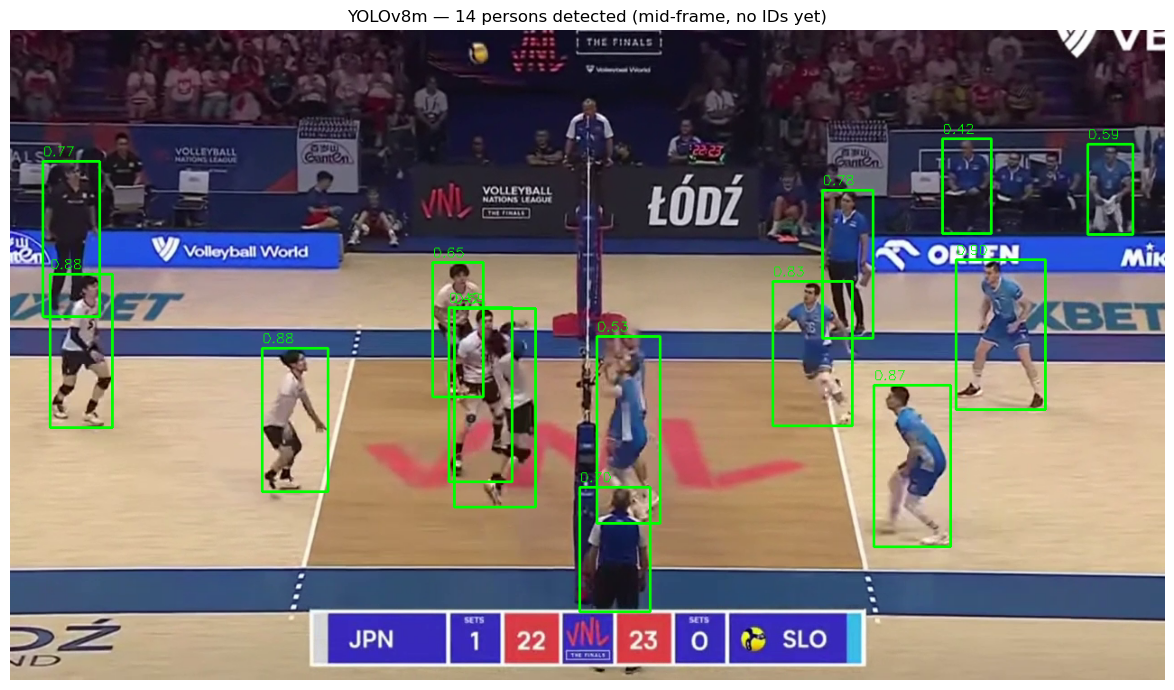

Detected 14 persons
Confidence range: 0.42 → 0.90


In [3]:
model = YOLO(MODEL_PATH)

# Test on the mid-point frame
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

# Apply area filter
areas      = (detections.xyxy[:,2] - detections.xyxy[:,0]) * (detections.xyxy[:,3] - detections.xyxy[:,1])
detections = detections[areas >= MIN_BOX_AREA]

# Visualise
viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(viz, f'{conf:.2f}', (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f'YOLOv8m — {len(detections)} persons detected (mid-frame, no IDs yet)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Detected {len(detections)} persons')
print(f'Confidence range: {detections.confidence.min():.2f} → {detections.confidence.max():.2f}')

## 4 — Helper Functions

In [4]:
from collections import deque

def filter_by_area(det: sv.Detections, min_area: float = MIN_BOX_AREA) -> sv.Detections:
    """Remove detections whose bounding-box area is below min_area pixels²."""
    w = det.xyxy[:, 2] - det.xyxy[:, 0]
    h = det.xyxy[:, 3] - det.xyxy[:, 1]
    return det[w * h >= min_area]


def is_stationary(history: deque) -> bool:
    """True when centroid hasn't moved STATIONARY_PIXELS over STATIONARY_FRAMES frames."""
    if len(history) < STATIONARY_FRAMES:
        return False
    pts = np.array(history)
    return (pts[:,0].max() - pts[:,0].min() < STATIONARY_PIXELS and
            pts[:,1].max() - pts[:,1].min() < STATIONARY_PIXELS)


def id_color(track_id: int):
    """Deterministic BGR colour per track ID."""
    rng = np.random.default_rng(int(track_id) * 7)
    return tuple(int(c) for c in rng.integers(80, 230, 3))


def draw_track(frame, box, tid, conf=None):
    x1, y1, x2, y2 = map(int, box)
    color = id_color(tid)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    label = f'ID {tid}' if conf is None else f'ID {tid}  {conf:.2f}'
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
    cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, cv2.FILLED)
    cv2.putText(frame, label, (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)


print('Helper functions defined.')

Helper functions defined.


## 5 — 50-Frame Tracking Preview (Sanity Check)

In [5]:
preview_tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS),
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<8} {'Raw dets':<12} {'Filtered':<12} {'Active IDs':<14} IDs")
print('─' * 65)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    raw        = sv.Detections.from_ultralytics(results)
    filtered   = filter_by_area(raw)
    tracked    = preview_tracker.update_with_detections(filtered)
    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f'{i:<8} {len(raw):<12} {len(filtered):<12} {len(ids):<14} {ids}')

cap.release()

Frame    Raw dets     Filtered     Active IDs     IDs
─────────────────────────────────────────────────────────────────
0        15           15           0              []
1        15           15           0              []
2        14           14           0              []
3        14           14           0              []
4        14           14           0              []
5        14           14           10             [2, 6, 4, 3, 5, 8, 9, 7, 10, 11]
6        14           14           11             [2, 4, 1, 6, 3, 9, 8, 5, 7, 10, 11]
7        14           14           11             [4, 2, 1, 6, 9, 3, 10, 7, 5, 8, 11]
8        13           13           10             [2, 1, 4, 3, 6, 5, 9, 7, 11, 10]
9        13           13           10             [2, 4, 1, 3, 6, 5, 9, 7, 11, 10]
10       13           13           11             [1, 2, 4, 3, 6, 5, 9, 7, 11, 10, 12]
11       12           12           11             [2, 4, 1, 3, 6, 9, 5, 11, 12, 8, 10]
12       13         

## 6 — Full Video Output

In [6]:
# Fresh tracker — never reuse a stateful tracker across runs
tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS),
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f'Cannot open VideoWriter: {OUTPUT_PATH}'

centroid_history: dict[int, deque] = {}
all_ids:  set[int] = set()
frame_idx = 0
start     = time.time()

print(f"Processing {TOTAL} frames → {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}ETA")
print('─' * 55, flush=True)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # ── Detect ──────────────────────────────────────────────────────────
    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = filter_by_area(sv.Detections.from_ultralytics(results))

    # ── Track ───────────────────────────────────────────────────────────
    tracked = tracker.update_with_detections(detections)

    # ── Update centroid history ──────────────────────────────────────────
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            cx, cy = int((box[0]+box[2])/2), int((box[1]+box[3])/2)
            if tid not in centroid_history:
                centroid_history[tid] = deque(maxlen=STATIONARY_FRAMES)
            centroid_history[tid].append((cx, cy))

    # ── Annotate ─────────────────────────────────────────────────────────
    annotated = frame.copy()
    active = 0
    if tracked.tracker_id is not None:
        for box, tid, conf in zip(tracked.xyxy, tracked.tracker_id, tracked.confidence):
            if is_stationary(centroid_history.get(int(tid), deque())):
                continue  # suppress non-moving spectators
            all_ids.add(int(tid))
            active += 1
            draw_track(annotated, box, int(tid), float(conf))

    # ── HUD overlay ───────────────────────────────────────────────────────
    elapsed  = max(time.time() - start, 1e-6)
    fps_live = (frame_idx + 1) / elapsed
    hud = f'Frame {frame_idx}  Active:{active}  IDs:{len(all_ids)}  {fps_live:.1f}fps'
    cv2.putText(annotated, hud, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (220,220,220), 1)

    writer.write(annotated)

    if frame_idx % 30 == 0:
        eta = (TOTAL - frame_idx) / max(fps_live, 1e-6)
        print(f'{frame_idx:<10}{len(detections):<8}{active:<10}{len(all_ids):<12}'
              f'{fps_live:<8.1f}ETA {eta:.0f}s', flush=True)

    frame_idx += 1

cap.release()
writer.release()

elapsed = time.time() - start
print(f'\n Done — {frame_idx} frames in {elapsed:.0f}s  ({frame_idx/elapsed:.1f} FPS avg)')
print(f'   Unique active IDs : {len(all_ids)}')
print(f'   Output            : {OUTPUT_PATH}')

Processing 1800 frames → C:\Users\Shruti Sharma\OneDrive\Documents\Motion-Object-Tracking\mot-tracker\notebooks\output.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
───────────────────────────────────────────────────────
0         15      0         0           1.3     ETA 1438s
30        12      10        13          1.2     ETA 1476s
60        17      11        13          1.2     ETA 1451s
90        15      14        16          1.2     ETA 1412s
120       14      11        16          1.2     ETA 1386s
150       14      10        17          1.2     ETA 1365s
180       15      12        21          1.2     ETA 1346s
210       12      11        22          1.2     ETA 1327s
240       15      10        23          1.2     ETA 1306s
270       15      11        24          1.2     ETA 1285s
300       15      11        25          1.2     ETA 1261s
330       11      11        26          1.2     ETA 1232s
360       12      10        28          1.2     ETA 1212s
390       15   

## 7 — Verify Output

Output file size: 71.1 MB


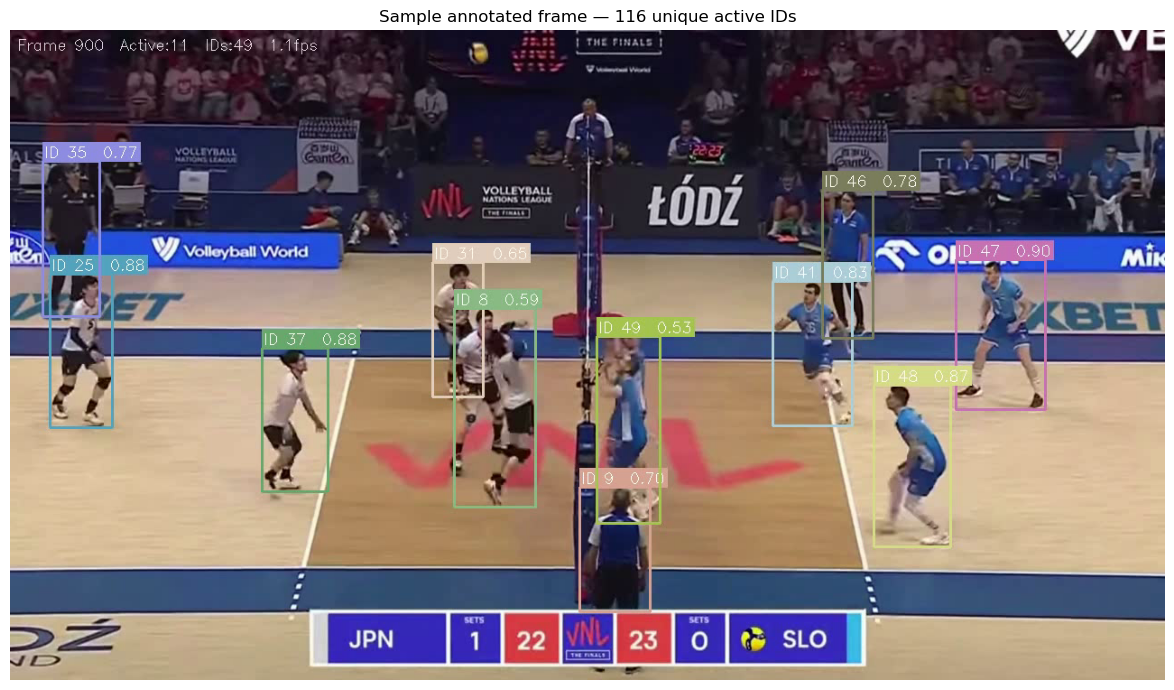

7yOutput verified: C:\Users\Shruti Sharma\OneDrive\Documents\Motion-Object-Tracking\mot-tracker\notebooks\output.mp4 (71.1 MB)


In [7]:
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f'Output file size: {size_mb:.1f} MB')
assert size_mb > 5, 'File too small — pipeline may have failed silently'

cap_out = cv2.VideoCapture(OUTPUT_PATH)
cap_out.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, sample = cap_out.read()
cap_out.release()

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f'Sample annotated frame — {len(all_ids)} unique active IDs')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'7yOutput verified: {OUTPUT_PATH} ({size_mb:.1f} MB)')